# Project 6 - The Sharpness Quest: cVAE with discriminator loss

Same data, encoder, decoder, reconstruction/KL loss and hyperparameters as the baseline. The only change is an extra adversarial term from a conditional discriminator.


## Imports 

In [1]:
import torch
import torch.nn as nn

from torch.utils.data  import DataLoader
from torchvision.datasets import MNIST
import torch.nn.functional as F
import torchvision.utils
from torch.utils.data import TensorDataset


from tqdm import tqdm
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import pickle
from torchvision.utils import make_grid

# use the GPU when available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


In [2]:
print("file size:", os.path.getsize('mnist_custom.pt'), "bytes (expected 112562040)")

d = torch.load('mnist_custom.pt', map_location='cpu', weights_only=False)

for k, v in d.items():
    print(k, tuple(v.shape), v.dtype, "min", float(v.min()), "max", float(v.max()))

bs_train = 1000
bs_test  = 1000

train_dataset = TensorDataset(d['train_images'], d['train_labels'])
test_dataset  = TensorDataset(d['test_images'],  d['test_labels'])

train_dataloader = DataLoader(train_dataset, batch_size=bs_train, shuffle=True,  num_workers=0)
test_dataloader  = DataLoader(test_dataset,  batch_size=bs_test,  shuffle=False, num_workers=0)

# check one batch
x, y = next(iter(train_dataloader))
print("batch:", x.shape, y.shape)

file size: 112562040 bytes (expected 112562040)
train_images (60000, 1, 20, 20) torch.float32 min 0.0 max 1.0
train_labels (60000,) torch.int64 min 0.0 max 9.0
test_images (10000, 1, 20, 20) torch.float32 min 0.0 max 1.0
test_labels (10000,) torch.int64 min 0.0 max 9.0
batch: torch.Size([1000, 1, 20, 20]) torch.Size([1000])


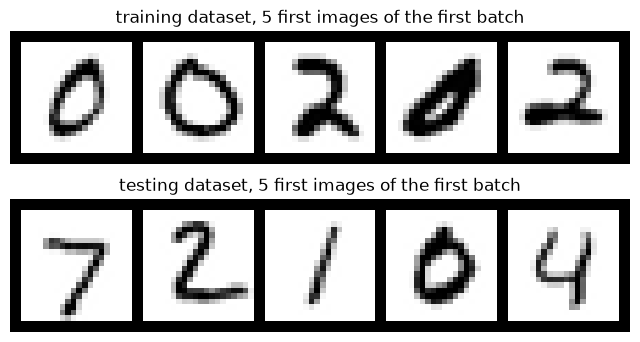

In [3]:
#%% create a figure showing one image per class
figure = plt.figure(figsize=(8, 4))
cols, rows = 3, 3

data,cond = next(iter(train_dataloader))
from torchvision.utils import make_grid
displayImage = make_grid(data[0:5], nrow = 5).permute(1, 2, 0) # need to scale back for display the effect of the normalisation
figure.add_subplot(2, 1, 1)
plt.title('training dataset, 5 first images of the first batch')
plt.axis("off")
plt.imshow(displayImage)

data,cond = next(iter(test_dataloader))
displayImage = make_grid(data[0:5], nrow = 5).permute(1, 2, 0) # need to scale back for display the effect of the normalisation
figure.add_subplot(2, 1, 2)
plt.title('testing dataset, 5 first images of the first batch')
plt.axis("off")
plt.imshow(displayImage)

plt.savefig('task1_fig1', dpi=300, transparent=False)
plt.show()

### Create an encoder 

In [4]:
# Create an encoder to encode the 1x20x20 images into a latent vector of dimension z_dim
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 64x3x3 -> 256x1x1 (kernel 3 instead of 4 for the 20x20 dataset)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn. Sequential(
           nn.Linear(256+num_classes, 2*z_dim)
        )
         
    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20)        
        # TODO: Implement the encoder network to map x, cond to mu and log-var
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim =1)
        x = self.encoder_head(x)
        mu, logvar=torch.chunk(x, 2, dim=1)
        return mu,logvar

### Create a Decoder

In [5]:
class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input =  nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256), 
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x5x5
            nn.ConvTranspose2d(256, 64, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            # Layer 2: 64x5x5 -> 32x10x10
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x10x10 -> 16x20x20
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 16x20x20 -> 1x20x20
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        # z shape: (batch_size, z_dim)
        # cond shape: (batch_size, num_classes)
        #TODO: inplement the decoder to generate a new sample from a latent vector and condition
        x = self.decoder_input(torch.cat([z, cond], dim=1))
        x_hat = self.decoder_backbone(x)
        return x_hat

### CVAE Loss

In [6]:
def compute_loss(x, x_hat, mu, logvar, beta=0.1):
    """
    Compute the reconstruction loss for the autoencoder.
    """

    # Reconstruction loss (MSE)

    recon_loss = F.mse_loss(x, x_hat)
    recon_loss = 100*recon_loss

    # For standard autoencoder, KL divergence is 0
    if beta == 0:
        kl_loss = 0.0
    else:
        kl_loss = torch.mean(-0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp(), dim=1))

    # Total loss
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

### Setting model 

In [7]:
class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim =  z_dim
        self.num_classes = num_classes
    
    def encode(self,x,cond):
        return self.encoder(x,cond)

    def decode(self,z,cond):
        return self.decoder(z,cond)
    
    def forward(self, x, cond):
        mu,logvar = self.encoder(x, cond)
        # TODO: implement the reparametrization trick to sample the latent z
        sigma = (0.5 *logvar).exp()
        eps = torch.randn_like(sigma)
        z = mu + sigma * eps 
        x_recon = self.decoder(z, cond)
        return x_recon,mu,logvar

### Dimension Set and Check

In [8]:
# parameters
z_dim = 7

# create the model and move it to the device
model = cVAE(z_dim,num_classes = 10)
model = model.to(device)

print(model)

print("\n---total number of parameters:")
Nparams = sum(p.numel() for p in model.parameters())
print(Nparams)
print("---total number of trainable parameters:")
Nparams_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(Nparams_train)
print()

# shape check on one batch: output must match the 20x20 input
x, y = next(iter(train_dataloader))
x_hat, mu, logvar = model(x.to(device), F.one_hot(y, 10).float().to(device))
print('input', tuple(x.shape), '-> recon', tuple(x_hat.shape), '| mu', tuple(mu.shape))
assert x_hat.shape == x.shape


cVAE(
  (encoder): cEncoder(
    (encoder_backbone): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1))
      (7): ReLU()
      (8): Flatten(start_dim=1, end_dim=-1)
    )
    (encoder_head): Sequential(
      (0): Linear(in_features=266, out_features=14, bias=True)
    )
  )
  (decoder): cDecoder(
    (decoder_input): Sequential(
      (0): Linear(in_features=17, out_features=256, bias=True)
      (1): ReLU()
    )
    (decoder_backbone): Sequential(
      (0): Unflatten(dim=1, unflattened_size=(256, 1, 1))
      (1): ConvTranspose2d(256, 64, kernel_size=(5, 5), stride=(1, 1))
      (2): ReLU()
      (3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    

### Conditional discriminator

The label is broadcast to 10 extra input channels, so D judges whether an image looks like a *real instance of that digit*. It outputs a logit (no sigmoid); `BCEWithLogitsLoss` handles that.


In [9]:
class cDiscriminator(nn.Module):
    def __init__(self, num_classes):
        super(cDiscriminator, self).__init__()
        self.num_classes = num_classes
        self.net = nn.Sequential(
            # 11x20x20 -> 32x10x10
            nn.Conv2d(1 + num_classes, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # 32x10x10 -> 64x5x5
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # 64x5x5 -> 128x3x3
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 1)   # real/fake logit
        )

    def forward(self, x, cond):
        c = cond[:, :, None, None].expand(-1, -1, x.size(2), x.size(3))
        return self.net(torch.cat([x, c], dim=1))

D = cDiscriminator(num_classes=10).to(device)
print(D)
print('discriminator parameters:', sum(p.numel() for p in D.parameters()))

# shape check
x, y = next(iter(train_dataloader))
print('D output', tuple(D(x.to(device), F.one_hot(y, 10).float().to(device)).shape))


cDiscriminator(
  (net): Sequential(
    (0): Conv2d(11, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1152, out_features=1, bias=True)
  )
)
discriminator parameters: 113505
D output (1000, 1)


## Training the cVAE with discriminator loss

Each batch alternates two updates:

1. **Discriminator step:** real images → 1; reconstructions and prior samples (z ~ N(0, I)) → 0. Generator outputs are detached.
2. **cVAE step:** `recon + beta*KL + lam_adv * adversarial`, where the adversarial term is the non-saturating loss −log D(x̂, y), applied to both reconstructions and prior samples. Prior samples are included because Task 3 evaluates samples from the prior.

`lam_adv` controls how strongly the discriminator shapes the decoder. Too large and training becomes unstable; too small and the model behaves like the baseline.


In [10]:
torch.manual_seed(0); np.random.seed(0); random.seed(0)

n_epochs = 100      # same as baseline
beta     = 0.1      # same as baseline
lam_adv  = 0.1      # weight of the discriminator term (hyperparameter to report)

model = cVAE(z_dim, num_classes=10).to(device)
D     = cDiscriminator(num_classes=10).to(device)
opt_vae = torch.optim.Adam(model.parameters(), lr=1e-3)                       # same as baseline
opt_D   = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))       # standard GAN setting
bce = nn.BCEWithLogitsLoss()

@torch.no_grad()
def eval_epoch(model, loader, beta):
    """Test-set [total, recon, kl] without the adversarial term, comparable to the baseline."""
    model.eval()
    tot = np.zeros(3); n = 0
    for x, y in loader:
        x = x.to(device); c = F.one_hot(y, 10).float().to(device)
        x_hat, mu, logvar = model(x, c)
        loss, rec, kl = compute_loss(x, x_hat, mu, logvar, beta)
        tot += [loss.item(), rec.item(), float(kl)]; n += 1
    return tot / n

# per epoch: train [total, recon, kl, adv, D loss, D(real) prob, D(fake) prob]
history = {'train': [], 'test': []}

for epoch in tqdm(range(n_epochs)):
    model.train(); D.train()
    tot = np.zeros(7); n = 0
    for x, y in train_dataloader:
        x = x.to(device); c = F.one_hot(y, 10).float().to(device)
        ones  = torch.ones(x.size(0), 1, device=device)
        zeros = torch.zeros(x.size(0), 1, device=device)

        x_hat, mu, logvar = model(x, c)
        z_p = torch.randn(x.size(0), z_dim, device=device)
        x_p = model.decode(z_p, c)

        # ---- 1) discriminator step ----
        d_real = D(x, c)
        d_rec  = D(x_hat.detach(), c)
        d_pri  = D(x_p.detach(), c)
        loss_D = bce(d_real, ones) + 0.5 * (bce(d_rec, zeros) + bce(d_pri, zeros))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # ---- 2) cVAE step (encoder + decoder) ----
        loss_vae, rec, kl = compute_loss(x, x_hat, mu, logvar, beta)
        adv = 0.5 * (bce(D(x_hat, c), ones) + bce(D(x_p, c), ones))
        loss = loss_vae + lam_adv * adv
        opt_vae.zero_grad(); loss.backward(); opt_vae.step()

        tot += [loss.item(), rec.item(), float(kl), adv.item(), loss_D.item(),
                torch.sigmoid(d_real).mean().item(),
                torch.sigmoid(torch.cat([d_rec, d_pri])).mean().item()]
        n += 1

    history['train'].append(tot / n)
    history['test'].append(eval_epoch(model, test_dataloader, beta))
    if epoch % 10 == 0 or epoch == n_epochs - 1:
        tr, te = history['train'][-1], history['test'][-1]
        print(f"epoch {epoch:3d} | recon {tr[1]:.3f} kl {tr[2]:.3f} adv {tr[3]:.3f} | "
              f"D loss {tr[4]:.3f} D(real) {tr[5]:.2f} D(fake) {tr[6]:.2f} | test recon {te[1]:.3f}")

torch.save(model.state_dict(), 'cvae_disc.pt')
torch.save(D.state_dict(), 'discriminator.pt')
with open('cvae_disc_history.pkl', 'wb') as f:
    pickle.dump({'history': history, 'lam_adv': lam_adv, 'beta': beta}, f)
print('saved cvae_disc.pt, discriminator.pt and cvae_disc_history.pkl')


  0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_1814/3900833319.py:53: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  tot += [loss.item(), rec.item(), float(kl), adv.item(), loss_D.item(),
  1%|          | 1/100 [00:12<20:44, 12.57s/it]

epoch   0 | recon 10.158 kl 1.506 adv 0.753 | D loss 1.293 D(real) 0.53 D(fake) 0.48 | test recon 5.895


 11%|█         | 11/100 [02:18<18:42, 12.61s/it]

epoch  10 | recon 2.813 kl 4.430 adv 1.609 | D loss 0.827 D(real) 0.72 D(fake) 0.29 | test recon 2.775


 21%|██        | 21/100 [04:24<16:38, 12.64s/it]

...

epoch  80 | recon 1.611 kl 8.120 adv 1.183 | D loss 1.069 D(real) 0.63 D(fake) 0.37 | test recon 1.652


 91%|█████████ | 91/100 [19:20<01:53, 12.64s/it]

epoch  90 | recon 1.586 kl 8.208 adv 1.161 | D loss 1.080 D(real) 0.63 D(fake) 0.37 | test recon 1.631


100%|██████████| 100/100 [21:13<00:00, 12.74s/it]

epoch  99 | recon 1.569 kl 8.282 adv 1.155 | D loss 1.071 D(real) 0.63 D(fake) 0.37 | test recon 1.603
saved cvae_disc.pt, discriminator.pt and cvae_disc_history.pkl


### Loss curves

If D(real) → 1 and D(fake) → 0 early and stay there, the discriminator is winning too easily and the adversarial gradient vanishes. Values hovering between about 0.3 and 0.7 indicate a healthy balance.


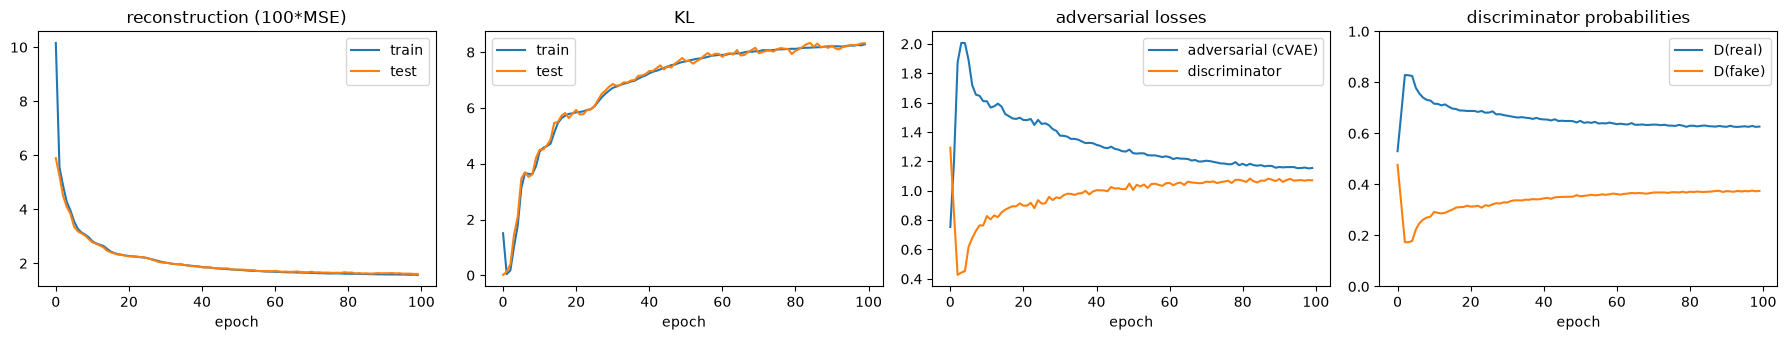

In [11]:
tr = np.array(history['train']); te = np.array(history['test'])
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
axes[0].plot(tr[:, 1], label='train'); axes[0].plot(te[:, 1], label='test')
axes[0].set_title('reconstruction (100*MSE)')
axes[1].plot(tr[:, 2], label='train'); axes[1].plot(te[:, 2], label='test')
axes[1].set_title('KL')
axes[2].plot(tr[:, 3], label='adversarial (cVAE)'); axes[2].plot(tr[:, 4], label='discriminator')
axes[2].set_title('adversarial losses')
axes[3].plot(tr[:, 5], label='D(real)'); axes[3].plot(tr[:, 6], label='D(fake)')
axes[3].set_title('discriminator probabilities'); axes[3].set_ylim(0, 1)
for ax in axes: ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout()
plt.savefig('disc_losses.png', dpi=300)
plt.show()


### Conditional sampling: 12 samples per digit (12x10 grid)

The same seed as the baseline gives identical latent vectors, so the two grids can be compared image by image.


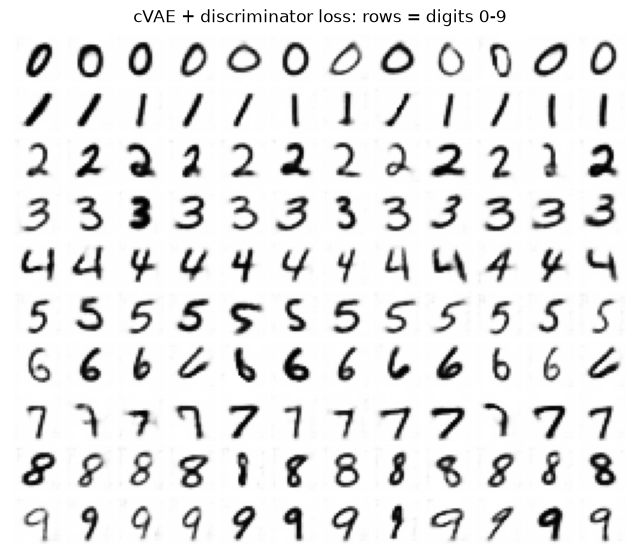

In [12]:
@torch.no_grad()
def sample_grid(model, n_per_class=12, seed=0, title=None):
    model.eval()
    g = torch.Generator(device='cpu').manual_seed(seed)
    y = torch.arange(10).repeat_interleave(n_per_class)
    z = torch.randn(len(y), model.z_dim, generator=g).to(device)
    x = model.decode(z, F.one_hot(y, 10).float().to(device)).cpu()
    grid = make_grid(x, nrow=n_per_class, pad_value=1)
    plt.figure(figsize=(8, 7))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    if title: plt.title(title)
    return x

samples_disc = sample_grid(model, title='cVAE + discriminator loss: rows = digits 0-9')
plt.savefig('disc_samples_grid.png', dpi=300)
plt.show()
